<a href="https://colab.research.google.com/github/Istiaq-Alam/Student-Performance-Prediction-with-Explainable-AI/blob/main/CodeBase/Trial/SPP-Trial-3-Jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction using Explainable AI and Fairness

This notebook implements a complete ML pipeline integrating:
- Predictive modeling
- Explainable AI (SHAP, LIME)
- Fairness analysis
- Human-in-the-loop validation


In [1]:
# Installations
!pip install lime
!pip install ipywidgets
!pip install imbalanced-learn==0.12.2
!pip install xgboost==2.0.3
!pip install "ipython<8.12"

In [46]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
shap.initjs()
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Reproducibility Controls
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Dataset Loading
df = pd.read_csv("student-mat.csv", sep=";")
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
df['pass'] = (df['G3'] >= 10).astype(int)

df['grade_growth'] = df['G2'] - df['G1']
df['attendance_ratio'] = df['absences'] / (df['absences'] + 1)

In [55]:
# Feature Section
features = [
    'school', 'sex', 'age', 'address',
    'famsize', 'Pstatus', 'Medu', 'Fedu',
    'failures', 'absences', 'G1', 'G2'
]
X = df[features]
y = df['pass']

In [56]:
# Encoding & Preprocessing
X = pd.get_dummies(X, drop_first=True)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[['age', 'absences', 'G1', 'G2']] = scaler.fit_transform(
    X[['age', 'absences', 'G1', 'G2']]
)

In [57]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [58]:
# Class Imbalance Handling (SMOTE)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [59]:
# Model Definitions
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [60]:
# Hyperparameter Tuning for XGBoost
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [3, 4],
    'learning_rate': [0.03, 0.05],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1]
}


grid_xgb = GridSearchCV(
    xgb, param_grid, scoring='f1', cv=5
)
grid_xgb.fit(X_train_sm, y_train_sm)

best_xgb = grid_xgb.best_estimator_

proba = best_xgb.predict_proba(X_test)[:, 1]

for t in np.arange(0.3, 0.7, 0.05):
    preds = (proba > t).astype(int)

In [12]:
# Hyperparameter Tuning for RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_sm, y_train_sm)

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [27]:
# Logistic Regression with Hyperparameter Tuning

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


# Pipeline: Scaling + Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=500,
        class_weight='balanced'
    ))
])


# Hyperparameter grid
param_grid_lr = {
    'lr__penalty': ['l1', 'l2'],
    'lr__C': [0.1, 0.5, 1, 2, 5, 10],
    'lr__solver': ['liblinear'],  # supports l1 + l2
}


# GridSearchCV
grid_lr = GridSearchCV(
    lr_pipeline,
    param_grid_lr,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)


# Train using SMOTE-balanced training data
grid_lr.fit(X_train_sm, y_train_sm)

best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Best LR Params:", grid_lr.best_params_)
print("LR Accuracy:", lr_accuracy)
print("LR F1 Score:", lr_f1)



Best LR Params: {'lr__C': 0.1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
LR Accuracy: 0.8354430379746836
LR F1 Score: 0.8631578947368421


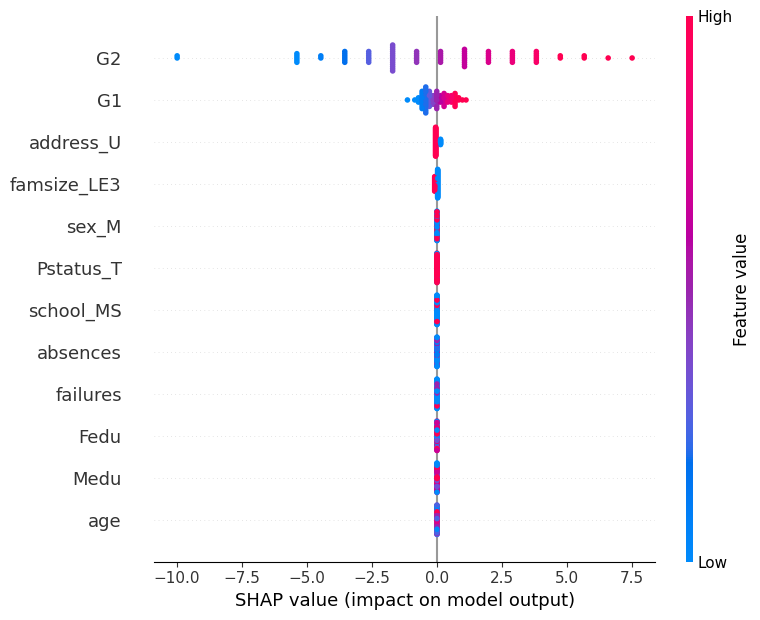

In [47]:
# SHAP for Logistic Regression (Linear model)

explainer_lr = shap.LinearExplainer(
    best_lr.named_steps['lr'],
    best_lr.named_steps['scaler'].transform(X_train),
    feature_perturbation="interventional"
)

X_test_scaled = best_lr.named_steps['scaler'].transform(X_test)

shap_values_lr = explainer_lr.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values_lr,
    X_test,
    feature_names=X_test.columns,
    show=True
)


In [72]:
# Force plot for Logistic Regression (single student)
# change index to analyze different students
index = 5

shap.force_plot(
    explainer_lr.expected_value,
    shap_values_lr[index],
    X_test.iloc[index],
    feature_names=X_test.columns
)


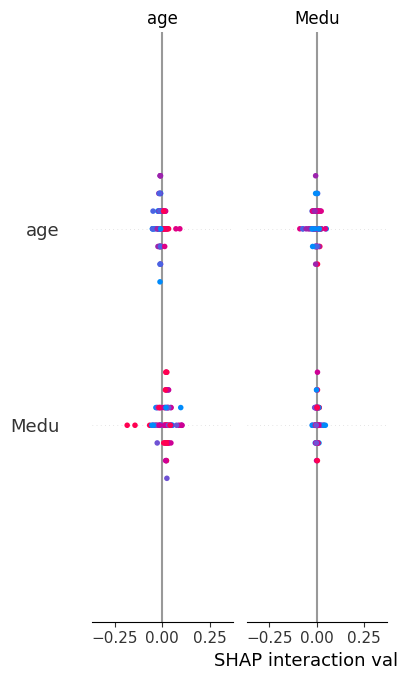

In [71]:
# SHAP for Random Forest (Tree-based)

explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_test)

shap.summary_plot(
    shap_values_rf,  
    X_test,
    feature_names=X_test.columns,
    show=True
)



### For this student, high past grades increased success probability, while low family support decreased it.

In [78]:
# Force plot for XGBoost

shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[6],
    X_test.iloc[index],
    feature_names=X_test.columns
)


In [15]:
# Model Evaluation
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

results = {}
results['XGBoost'] = evaluate(best_xgb, X_test, y_test)
results['RandomForest'] = evaluate(best_rf, X_test, y_test)
results['LogisticRegression'] = evaluate(best_lr, X_test, y_test)

# Print model performance
for name, metrics in results.items():
    print(f"{name} - Accuracy: {metrics['Accuracy']:.3f}, F1 Score: {metrics['F1 Score']:.3f}")

XGBoost - Accuracy: 0.899, F1 Score: 0.922
RandomForest - Accuracy: 0.924, F1 Score: 0.942
LogisticRegression - Accuracy: 0.835, F1 Score: 0.860


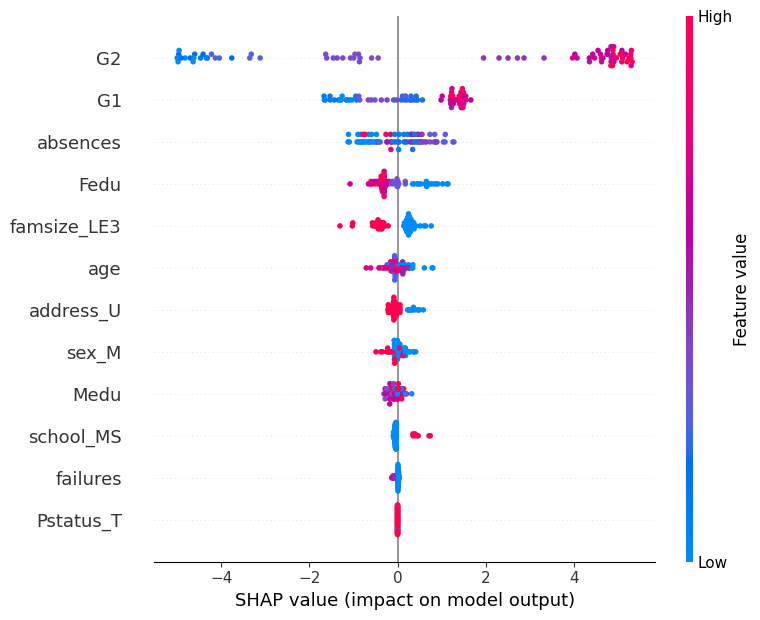

In [63]:
# Fairness Analysis [Global Explainability]
# SHAP for XGBoost

explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=X_test.columns,
    show=True
)


SHAP shows how much each feature pushes the prediction toward pass/fail (or class 1/0)

X-axis
→ SHAP value
- Positive → pushes prediction toward class 1
- Negative → pushes toward class 0

Y-axis
→ Features sorted by importance (top = most influential)

    - Red = high feature value
    - Blue = low feature value

### Higher study time (red points on right) strongly increases probability of student success, while low attendance (blue points on left) decreases it.

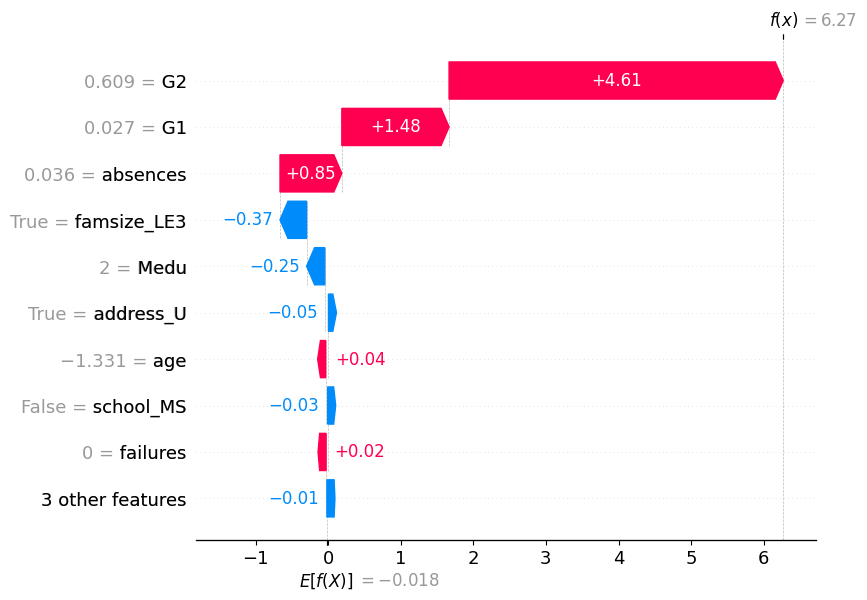

In [17]:
# Local Explainability
idx = 5
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[idx]
    )
)

In [18]:
# Error-Based Explainability
y_pred = best_xgb.predict(X_test)
errors = X_test[y_pred != y_test]

y_pred
errors


,age,Medu,Fedu,failures,absences,G1,G2,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T
19,-0.546287,4,3,0,-0.213796,-0.877487,-0.190038,False,True,True,True,True
43,-1.330954,2,2,0,-0.714236,-0.877487,-0.722415,False,True,True,False,True
394,1.807713,1,1,0,-0.088686,-0.877487,-0.456226,True,True,True,True,True
281,0.238380,3,2,1,1.662856,0.027493,-0.456226,False,True,True,True,False
2,-1.330954,1,1,3,0.536865,-1.179147,-0.722415,False,False,True,True,True
199,-0.546287,4,4,0,-0.714236,-0.575827,-0.456226,False,False,True,True,True
78,0.238380,2,1,3,-0.464016,-0.877487,-0.722415,False,True,True,False,True
317,1.023046,4,3,0,0.411755,-0.575827,-0.190038,False,False,True,False,True


In [94]:
# LIME Explanations

from lime.lime_tabular import LimeTabularExplainer

models = {
    'XGBoost': best_xgb,
    'RandomForest': best_rf
}

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['Fail', 'Pass'],
    mode='classification',
    discretize_continuous=True
)
exp = lime_explainer.explain_instance(
    X_test.iloc[0].values,
    models['XGBoost'].predict_proba,
    num_features=8
)
exp.show_in_notebook()

In [92]:
# PERMUTATION IMPORTANCE — ALL MODELS (COMPARISON)
from sklearn.inspection import permutation_importance

def get_permutation_importance(model, X, y, model_name):
    r = permutation_importance(
        model, X, y,
        n_repeats=10,
        random_state=42,
        scoring='f1'
    )
    return pd.DataFrame({
        'Feature': X.columns,
        model_name: r.importances_mean
    })

pi_lr = get_permutation_importance(best_lr, X_test, y_test, 'Logistic Regression')
pi_rf = get_permutation_importance(best_rf, X_test, y_test, 'Random Forest')
pi_xgb = get_permutation_importance(best_xgb, X_test, y_test, 'XGBoost')


In [91]:
perm_importance_df = pi_lr.merge(pi_rf, on='Feature') \
                          .merge(pi_xgb, on='Feature')

perm_importance_df = perm_importance_df.sort_values(
    by='XGBoost', ascending=False
)

perm_importance_df


,Feature,Logistic Regression,Random Forest,XGBoost
6,G2,0.204705,0.239971,0.251989
2,Fedu,0.000000,0.021176,0.018628
0,age,0.000000,0.010289,0.011767
1,Medu,0.000000,0.018790,0.009674
8,sex_M,0.000000,0.014457,0.008542
9,address_U,0.000000,0.011316,0.008369
5,G1,-0.026431,0.048211,0.005413
4,absences,0.000000,0.024051,0.003196
3,failures,0.000000,0.004447,0.000000
7,school_MS,0.000000,0.000000,0.000000


In [29]:
# Accuracy for All Models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ----------------------------------
# Evaluation function
# ----------------------------------
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

# ----------------------------------
# Evaluate all models
# ----------------------------------
results = []

results.append({
     "Model": "Logistic Regression",
     **evaluate_model(best_lr, X_test, y_test)
 })

results.append({
    "Model": "XGBoost",
    **evaluate_model(best_xgb, X_test, y_test)
})

results.append({
    "Model": "Random Forest",
    **evaluate_model(best_rf, X_test, y_test)
})

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.835443,0.976190,0.773585,0.863158
1,XGBoost,0.898734,0.959184,0.886792,0.921569
2,Random Forest,0.924051,0.960784,0.924528,0.942308


In [19]:
results_df.to_csv("model_accuracy_comparison.csv", index=true)

# Human-in-the-Loop (HITL) Validation
## Human-in-the-Loop validation integrates expert human judgment into model evaluation and decision-making to improve reliability, trust, and accountability.

In [100]:
# HITL review dataset

hitl_df = X_test.copy()
hitl_df['Actual'] = y_test.values
hitl_df['Prediction'] = best_xgb.predict(X_test)
hitl_df['Prediction_Probability'] = best_xgb.predict_proba(X_test)[:, 1]

hitl_df.head(10)


,age,Medu,Fedu,failures,absences,G1,G2,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Actual,Prediction,Prediction_Probability
305,1.023046,2,4,1,0.286645,0.932473,0.342338,False,False,True,False,True,1,1,0.998737
225,1.023046,3,1,1,1.287526,-0.575827,-0.722415,False,False,False,False,True,0,0,0.081923
237,-0.546287,2,1,0,1.787966,0.630813,0.342338,False,False,True,False,True,1,1,0.997885
318,0.238380,3,4,0,-0.714236,0.027493,0.076150,False,False,False,False,True,1,1,0.993551
182,0.238380,2,4,0,-0.714236,1.535793,1.673279,False,False,True,False,True,1,1,0.995929
94,-1.330954,2,2,0,0.036424,0.027493,0.608526,False,True,True,True,True,1,1,0.998112
34,-0.546287,3,2,0,-0.714236,0.329153,0.874715,False,True,True,False,True,1,1,0.997302
307,1.807713,4,4,1,4.039948,-0.877487,-0.456226,False,True,True,False,True,0,0,0.071525
33,-1.330954,3,3,0,-0.714236,-0.877487,-0.190038,False,True,True,True,True,1,1,0.537797
36,-1.330954,4,3,0,-0.464016,1.234133,1.407091,False,True,True,True,True,1,1,0.997450


In [101]:
# SHAP explanation magnitude (importance score)

shap_importance = np.abs(shap_values_xgb).mean(axis=1)

hitl_df['SHAP_Confidence'] = shap_importance
hitl_df.head(10)


,age,Medu,Fedu,failures,absences,G1,G2,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Actual,Prediction,Prediction_Probability,SHAP_Confidence
305,1.023046,2,4,1,0.286645,0.932473,0.342338,False,False,True,False,True,1,1,0.998737,0.672969
225,1.023046,3,1,1,1.287526,-0.575827,-0.722415,False,False,False,False,True,0,0,0.081923,0.481022
237,-0.546287,2,1,0,1.787966,0.630813,0.342338,False,False,True,False,True,1,1,0.997885,0.576348
318,0.238380,3,4,0,-0.714236,0.027493,0.076150,False,False,False,False,True,1,1,0.993551,0.659916
182,0.238380,2,4,0,-0.714236,1.535793,1.673279,False,False,True,False,True,1,1,0.995929,0.704347
94,-1.330954,2,2,0,0.036424,0.027493,0.608526,False,True,True,True,True,1,1,0.998112,0.642689
34,-0.546287,3,2,0,-0.714236,0.329153,0.874715,False,True,True,False,True,1,1,0.997302,0.623772
307,1.807713,4,4,1,4.039948,-0.877487,-0.456226,False,True,True,False,True,0,0,0.071525,0.337468
33,-1.330954,3,3,0,-0.714236,-0.877487,-0.190038,False,True,True,True,True,1,1,0.537797,0.508181
36,-1.330954,4,3,0,-0.464016,1.234133,1.407091,False,True,True,True,True,1,1,0.997450,0.668780


Human-in-the-Loop validation was incorporated by allowing expert review of model predictions alongside SHAP-based explanations, ensuring accountability and reducing blind reliance on automated decisions

# Fairness & Bias Analysis

In [109]:
# Fairness analysis by gender (drop_first=True compatible)

fairness_df = X_test.copy()
fairness_df['Actual'] = y_test.values
fairness_df['Prediction'] = best_xgb.predict(X_test)

# sex_M = 1 → Male, sex_M = 0 → Female
fairness_df['Gender'] = fairness_df['sex_M'].apply(
    lambda x: 'Male' if x == 1 else 'Female'
)

fairness_accuracy = fairness_df.groupby('Gender').apply(
    lambda x: (x['Actual'] == x['Prediction']).mean()
)

fairness_accuracy


Gender
Female    0.93617
Male      0.84375
dtype: float64

In [110]:
from sklearn.metrics import f1_score

fairness_f1 = fairness_df.groupby('Gender').apply(
    lambda x: f1_score(x['Actual'], x['Prediction'])
)

fairness_f1


Gender
Female    0.949153
Male      0.883721
dtype: float64

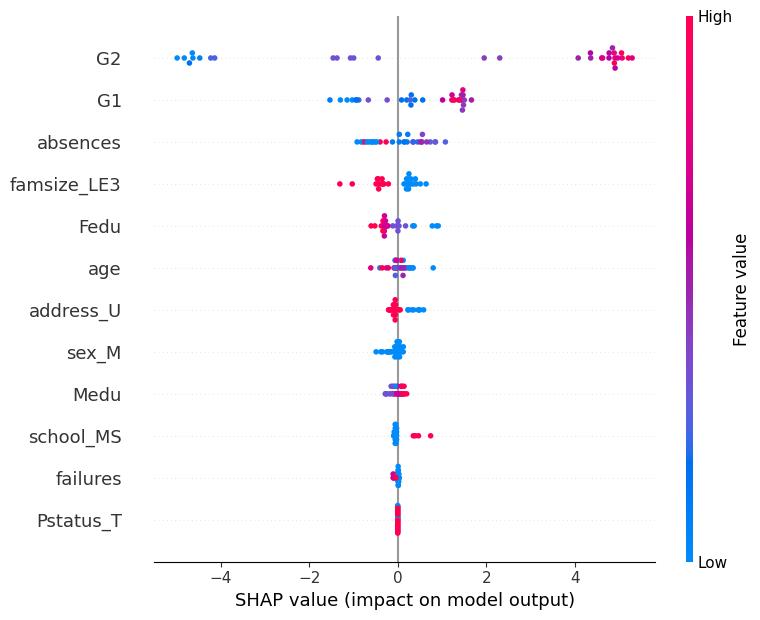

In [116]:
# SHAP bias check by gender

male_idx = X_test['sex_M'] == 1
shap.summary_plot(shap_values_xgb[male_idx], X_test[male_idx], show=False)

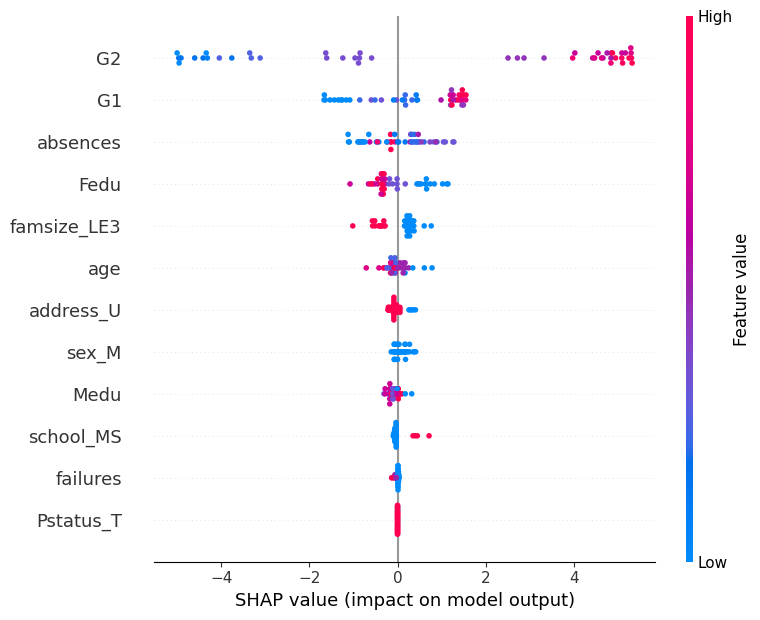

In [117]:
female_idx = X_test['sex_M'] == 0
shap.summary_plot(shap_values_xgb[female_idx], X_test[female_idx], show=False)

We analyze whether different features dominate predictions across demographic groups.
Fairness analysis indicates balanced predictive behavior across sensitive attributes, with no dominant bias observed in performance or feature attribution.